In [1]:
import random

In [2]:
text = """
Artificial intelligence is transforming the world.
Machine learning is a subset of artificial intelligence.
Deep learning is widely used in computer vision and natural language processing.
AI systems can learn patterns from data.
"""

In [3]:
class MarkovChainGenerator:

    def __init__(self):
        self.model = {}

    def train(self, text):
        words = text.split()

        for i in range(len(words) - 1):

            word = words[i]
            next_word = words[i + 1]

            if word not in self.model:
                self.model[word] = []

            self.model[word].append(next_word)

    def generate(self, start_word, length=20):

        if start_word not in self.model:
            return "Start word not found."

        result = [start_word]
        current_word = start_word

        for _ in range(length):

            next_words = self.model.get(current_word)

            if not next_words:
                break

            next_word = random.choice(next_words)

            result.append(next_word)

            current_word = next_word

        return " ".join(result)

In [4]:
generator = MarkovChainGenerator()

generator.train(text)

output = generator.generate("Artificial", 20)

print("Generated Text:\n")
print(output)

Generated Text:

Artificial intelligence is widely used in computer vision and natural language processing. AI systems can learn patterns from data.


In [5]:
!pip install networkx

In [6]:
import random
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
text = """
Artificial intelligence is transforming the world.
Machine learning is a subset of artificial intelligence.
Deep learning is widely used in computer vision and natural language processing.
AI systems can learn patterns from data and make predictions.
Artificial intelligence is the future of technology.
"""

In [8]:
words = text.lower().split()

print("Total Words:", len(words))
print(words[:20])

Total Words: 43
['artificial', 'intelligence', 'is', 'transforming', 'the', 'world.', 'machine', 'learning', 'is', 'a', 'subset', 'of', 'artificial', 'intelligence.', 'deep', 'learning', 'is', 'widely', 'used', 'in']


In [9]:
words = text.lower().split()

print("Total Words:", len(words))
print(words[:20])

Total Words: 43
['artificial', 'intelligence', 'is', 'transforming', 'the', 'world.', 'machine', 'learning', 'is', 'a', 'subset', 'of', 'artificial', 'intelligence.', 'deep', 'learning', 'is', 'widely', 'used', 'in']


In [10]:
def generate_bigram(start_word, length=20):

    result = [start_word]
    current = start_word

    for i in range(length):

        if current not in bigram_model:
            break

        next_word = random.choice(bigram_model[current])

        result.append(next_word)
        current = next_word

    return " ".join(result)

In [12]:
bigram_model = {}
for i in range(len(words) - 1):
    word = words[i]
    next_word = words[i + 1]
    if word not in bigram_model:
        bigram_model[word] = []
    bigram_model[word].append(next_word)

print(generate_bigram("artificial",20))

artificial intelligence. deep learning is transforming the future of technology.


In [16]:
trigram_model = {}

for i in range(len(words)-2):

    key = (words[i], words[i+1])
    next_word = words[i+2]

    if key not in trigram_model:
        trigram_model[key] = []

    trigram_model[key].append(next_word)

print("Sample Trigram:", list(trigram_model.items())[:3])

Sample Trigram: [(('artificial', 'intelligence'), ['is', 'is']), (('intelligence', 'is'), ['transforming', 'the']), (('is', 'transforming'), ['the'])]


In [17]:
def generate_trigram(w1, w2, length=20):

    result = [w1, w2]

    for i in range(length):

        key = (w1, w2)

        if key not in trigram_model:
            break

        next_word = random.choice(trigram_model[key])

        result.append(next_word)

        w1 = w2
        w2 = next_word

    return " ".join(result)

In [ ]:
print(generate_trigram("artificial","intelligence",20))

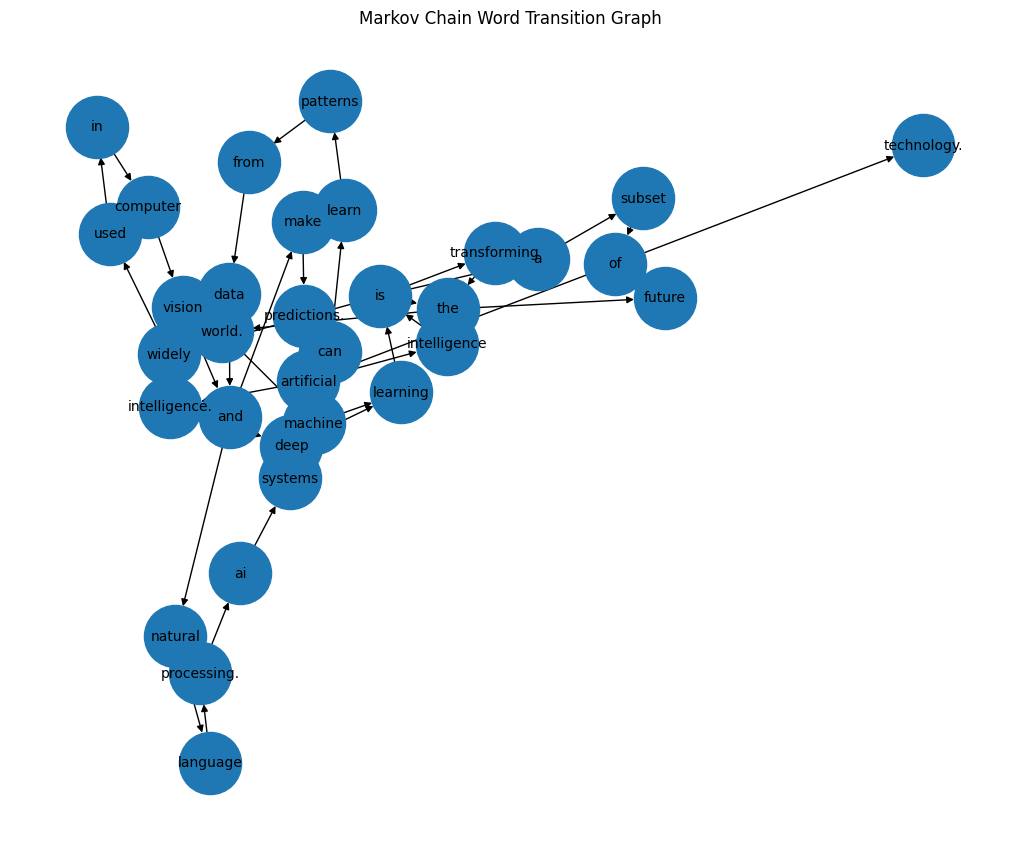

In [13]:
G = nx.DiGraph()

for word in bigram_model:
    for next_word in bigram_model[word]:
        G.add_edge(word,next_word)

plt.figure(figsize=(10,8))
nx.draw(G,with_labels=True,node_size=2000,font_size=10)
plt.title("Markov Chain Word Transition Graph")
plt.show()

In [15]:
trigram_model = {}

for i in range(len(words)-2):

    key = (words[i], words[i+1])
    next_word = words[i+2]

    if key not in trigram_model:
        trigram_model[key] = []

    trigram_model[key].append(next_word)

def generate_trigram(w1, w2, length=20):

    result = [w1, w2]

    for i in range(length):

        key = (w1, w2)

        if key not in trigram_model:
            break

        next_word = random.choice(trigram_model[key])

        result.append(next_word)

        w1 = w2
        w2 = next_word

    return " ".join(result)

print("Bigram Text:")
print(generate_bigram("artificial",15))

print("\nTrigram Text:")
print(generate_trigram("artificial","intelligence",15))

Bigram Text:
artificial intelligence is widely used in computer vision and make predictions. artificial intelligence. deep learning is

Trigram Text:
artificial intelligence is the future of technology.
